In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB
import time

In [ ]:
# ================== 数据加载与预处理 ==================
DATA_PATH = "./data/test_prices.csv"  # 请替换为实际路径
predict_DATA_PATH = "./forecast/prediction_results.csv"  # 请替换为实际路径
full_data = pd.read_csv(DATA_PATH)
predict_data= pd.read_csv(predict_DATA_PATH)
# 提取电价数据
# prices = full_data.iloc[:, -1].values
all_true_prices = predict_data.iloc[:, -2].values
all_predict_prices = predict_data.iloc[:, -1].values
# 选取连续96时段作为测试数据
start_idx = 0  # 可调整测试起点
NUM_STEPS = 96*3  # 测试步数
FORCAST_HORIZON = 48  # 预测步长
true_prices = all_true_prices[start_idx:start_idx+NUM_STEPS]
predict_prices = all_predict_prices[start_idx:start_idx+NUM_STEPS]

In [9]:
# ================== 储能系统参数 ==================
class EnergyStorage:
    def __init__(self):
        self.capacity = 2.0  # 储能容量 (MWh)
        self.max_charge = 0.2  # 最大充电功率 (MW)
        self.max_discharge = 0.2  # 最大放电功率 (MW)
        self.efficiency = 0.95  # 充电效率
        self.soc_min = 0.05  # 最小SOC (20%)
        self.soc_max = 0.95  # 最大SOC (90%)
        self.soc_init = 0.05  # 初始SOC (50%)

# ================== MPC控制器 ==================
class GurobiMPCController:
    def __init__(self, storage, H):
        """
        初始化MPC控制器
        
        参数:
        storage: EnergyStorage实例
        H: 预测时域长度 (默认24时段, 6小时)
        """
        self.storage = storage
        self.H = H  # 预测时域
        self.model = None  # Gurobi模型
        self.last_solve_time = 0  # 记录上次求解时间
        
        # 创建Gurobi环境并设置禁止输出
        self.env = gp.Env(empty=True)
        self.env.setParam('OutputFlag', 0)
        self.env.start()
    def build_model(self, current_soc, price_forecast):
        H_effective = min(self.H, len(price_forecast))
        
        # 创建Gurobi模型
        model = gp.Model("Battery_MPC", env=self.env)
        model.Params.LogToConsole = 0  # 关闭控制台输出
        model.Params.TimeLimit = 5  # 5秒求解时间限制
        model.Params.NumericFocus = 2  # 更高的数值精度要求
        
        # 创建变量
        P_char = model.addVars(H_effective, lb=0, ub=self.storage.max_charge, name="P_charge")
        P_dis = model.addVars(H_effective, lb=0, ub=self.storage.max_discharge, name="P_discharge")
        SOC = model.addVars(H_effective + 1, lb=self.storage.soc_min, ub=self.storage.soc_max, name="SOC")
        
        # 初始条件约束
        model.addConstr(SOC[0] == current_soc, "init_soc")
        
        # 系统动力学约束
        for k in range(H_effective):
            # SOC更新方程: SOC[k+1] = SOC[k] + efficiency*P_char*k - P_dis[k]/efficiency
            charge_effect = self.storage.efficiency * P_char[k]
            discharge_effect = - (P_dis[k] / self.storage.efficiency)
            
            model.addConstr(SOC[k+1] == SOC[k] + charge_effect + discharge_effect,f"soc_dynamics_{k}")
            
            # 互斥约束：不能同时充放电（使用大M法）
            M = self.storage.max_charge + self.storage.max_discharge
            bin_var = model.addVar(vtype=GRB.BINARY, name=f"bin_{k}")
            
            # 约束：如果充电，则放电为0；反之亦然
            model.addConstr(P_char[k] <= bin_var * M, f"char_cons_{k}")
            model.addConstr(P_dis[k] <= (1 - bin_var) * M, f"dis_cons_{k}")
        
        # 目标函数：最大化收益
        revenue = gp.quicksum(
            (P_dis[k] * price_forecast[k] * self.storage.efficiency) - 
            (P_char[k] * price_forecast[k] / self.storage.efficiency)
            for k in range(H_effective))
        model.setObjective(revenue, GRB.MAXIMIZE)

        return model, P_char, P_dis
    
    def solve_step(self, current_soc, price_forecast):
            start_time = time.time()
            
            try:
                # 构建并求解模型
                model, P_char, P_dis = self.build_model(current_soc, price_forecast)
                model.optimize(lambda model, where: None)
                
                # 检查求解状态
                if model.status == GRB.OPTIMAL or model.status == GRB.TIME_LIMIT:
                    # 获取当前时段决策
                    charge_power = P_char[0].X
                    discharge_power = P_dis[0].X
                else:
                    # 求解失败，返回安全决策
                    print(f"求解失败！状态码: {model.status}")
                    charge_power, discharge_power = 0, 0
            except gp.GurobiError as e:
                print(f"Gurobi错误: {e}")
                charge_power, discharge_power = 0, 0
            except Exception as e:
                print(f"未知错误: {e}")
                charge_power, discharge_power = 0, 0
            
            # 记录求解时间
            self.last_solve_time = time.time() - start_time
            #打印charge和discharge功率
            return charge_power, discharge_power
        
    def forecast_prices(self, t, true_sequence):
        # 剩余时段处理
        remain = len(true_sequence) - t
        forecast = true_sequence[t:t+self.H].copy()
        
        # 边界填充 (零填充)
        if remain < self.H:
            forecast = np.concatenate([forecast, np.zeros(self.H - remain)])

        
        return forecast

===== 储能系统MPC控制仿真 =====
Initializing Energy Storage with capacity 2.0 MWh
Initializing MPC Controller with horizon H=48 steps (12.0 hours)
运行MPC仿真...
Time 0: Charge Power: 0.2, Discharge Power: 0.0
Time 0: Revenue: -5.32,price: 25.26
Time 0:  SOC Change: 0.10
Time 1: Charge Power: 0.2, Discharge Power: 0.0
Time 1: Revenue: -5.32,price: 25.26
Time 1:  SOC Change: 0.10
Time 2: Charge Power: 0.14736842105263165, Discharge Power: 0.0
Time 2: Revenue: -3.95,price: 25.49
Time 2:  SOC Change: 0.07
Time 3: Charge Power: 0.2, Discharge Power: 0.0
Time 3: Revenue: -5.37,price: 25.49
Time 3:  SOC Change: 0.10
Time 4: Charge Power: 0.2, Discharge Power: 0.0
Time 4: Revenue: -5.37,price: 25.49
Time 4:  SOC Change: 0.10
Time 5: Charge Power: 0.2, Discharge Power: 0.0
Time 5: Revenue: -5.37,price: 25.49
Time 5:  SOC Change: 0.10
Time 6: Charge Power: 0.0, Discharge Power: 0.0
Time 6: Revenue: 0.00,price: 28.00
Time 6:  SOC Change: 0.00
Time 7: Charge Power: 0.0, Discharge Power: 0.0
Time 7: Revenue: 

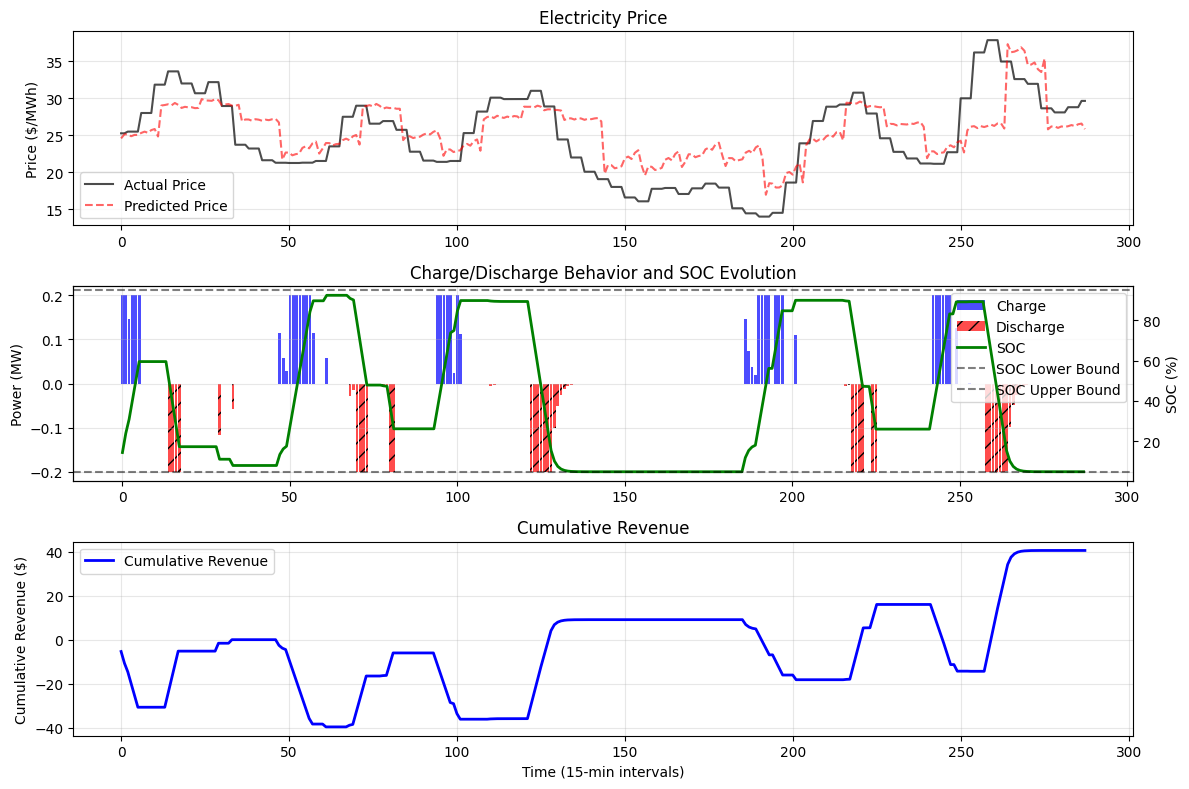

结果已导出到 mpc_results.csv
总收益: $40.69
===== 仿真完成! =====


In [ ]:
# ================== 模拟执行框架 ==================
class MPCStorageSimulator:
    def __init__(self, storage_params=None, H=24):
        # 创建储能系统
        self.storage = EnergyStorage()
        print(f"Initializing Energy Storage with capacity {self.storage.capacity} MWh")
        if storage_params:
            for key, value in storage_params.items():
                setattr(self.storage, key, value)
        
        # 创建MPC控制器
        print(f"Initializing MPC Controller with horizon H={H} steps ({H*0.25} hours)")
        self.controller = GurobiMPCController(self.storage, H=H)
        
        # 存储结果
        self.results = {}
    
    def run_simulation(self, price_sequence):
        # 初始化记录
        actions = {'charge': np.zeros(NUM_STEPS), 'discharge': np.zeros(NUM_STEPS)}
        soc_trace = np.zeros(NUM_STEPS)
        revenues = np.zeros(NUM_STEPS)
        solve_times = np.zeros(NUM_STEPS)
        current_soc = self.storage.soc_init
        
        # 逐时段滚动优化
        for t in range(NUM_STEPS):
            # 1. 生成电价预测 (使用真实值)
            price_forecast = self.controller.forecast_prices(t, price_sequence)
            # print(f"Time {t}: Price Forecast: {price_forecast}")
            
            # 2. 求解MPC优化
            P_char, P_dis = self.controller.solve_step(current_soc, price_forecast)
            print(f"Time {t}: Charge Power: {P_char}, Discharge Power: {P_dis}")

            # 3. 执行决策并更新状态
            revenue = (P_dis * price_sequence[t] * self.storage.efficiency -
                      P_char * price_sequence[t] / self.storage.efficiency)
            print(f"Time {t}: Revenue: {revenue:.2f},price: {price_sequence[t]:.2f}")
            # 更新SOC (考虑时间间隔)
            energy_change = (self.storage.efficiency * P_char - 
                           P_dis / self.storage.efficiency)
            print(f"Time {t}:  SOC Change: {energy_change / self.storage.capacity:.2f}")
            current_soc += energy_change / self.storage.capacity
            current_soc = np.clip(current_soc, self.storage.soc_min, self.storage.soc_max)
            
            # 4. 记录结果
            actions['charge'][t] = P_char
            actions['discharge'][t] = P_dis
            soc_trace[t] = current_soc
            revenues[t] = revenue
            solve_times[t] = self.controller.last_solve_time

        # 计算总收益
        total_revenue = np.sum(revenues)
        
        # 检查约束违规
        constraint_violation = np.sum(
            (soc_trace < self.storage.soc_min) | 
            (soc_trace > self.storage.soc_max)
        )
        
        return {
            'actions': actions,
            'soc': soc_trace,
            'revenue': total_revenue,
            'each_revenue': revenues,
            'end_soc': soc_trace[-1],
            'constraint_violation': constraint_violation
        }
    
    def visualize_results(self, results):
        """可视化仿真结果"""
        if not results:
            print("No results available for visualization!")
            return
        
        # 创建3个子图的布局
        fig, axes = plt.subplots(3, 1, figsize=(12, 8))
        fig.tight_layout(pad=5.0)
        
        # 1. 电价图
        ax1 = axes[0]
        # 反标准化电价: (norm_price * std) + mean
        ax1.plot(true_prices, 'k-', label='Actual Price', alpha=0.7)
        ax1.plot(predict_prices, 'r--', label='Predicted Price', alpha=0.6)
        ax1.set_ylabel('Price ($/MWh)')
        ax1.set_title('Electricity Price')
        ax1.grid(alpha=0.3)
        ax1.legend()
        
        # 2. 充放电行为和SOC变化
        ax2 = axes[1]
        # 创建第二个Y轴用于SOC
        ax2_soc = ax2.twinx()
        
        # 绘制充放电柱状图
        actions = results['actions']
        # 充电功率 (正值)
        ax2.bar(np.arange(NUM_STEPS), actions['charge'], 
                width=0.8, color='b', alpha=0.7,
                label="Charge")
        
        # 放电功率 (负值)
        ax2.bar(np.arange(NUM_STEPS), -actions['discharge'], 
                width=0.8, color='r', alpha=0.7,
                hatch='//', label="Discharge")
        
        # 绘制SOC折线图
        soc_data = results['soc']
        ax2_soc.plot(np.arange(NUM_STEPS), soc_data * 100, 'g-', 
                     linewidth=2, label="SOC")
        
        # 添加SOC限制线
        ax2_soc.axhline(self.storage.soc_min * 100, color='k', linestyle='--', alpha=0.5, label='SOC Lower Bound')
        ax2_soc.axhline(self.storage.soc_max * 100, color='k', linestyle='--', alpha=0.5, label='SOC Upper Bound')
        
        ax2.set_ylabel('Power (MW)')
        ax2_soc.set_ylabel('SOC (%)')
        ax2.set_title('Charge/Discharge Behavior and SOC Evolution')
        ax2.grid(alpha=0.3)
        
        # 合并图例
        lines, labels = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2_soc.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper right')
        
        # 3. 累计收益
        ax3 = axes[2]
        # 计算累计收益
        revenue_cum = np.cumsum([
            actions['discharge'][t] * true_prices[t] * self.storage.efficiency -
            actions['charge'][t] * true_prices[t] / self.storage.efficiency
            for t in range(NUM_STEPS)
        ]) 
        
        ax3.plot(revenue_cum, 'b-', 
                 linewidth=2, 
                 label="Cumulative Revenue")
        
        ax3.set_ylabel('Cumulative Revenue ($)')
        ax3.set_xlabel('Time (15-min intervals)')
        ax3.set_title('Cumulative Revenue')
        ax3.legend()
        ax3.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('mpc_results.png', dpi=300)
        plt.show()
        
    
    def generate_report(self, results):
        """生成性能报告"""
        if not results:
            print("No results available for reporting!")
            return
        
        print("\n" + "="*60)
        print("Energy Storage MPC Performance Report")
        print("="*60)
        
        # 表头
        print("\n{:<12} {:<15} {:<12} ".format(
            "Revenue($)", "Final SOC(%)", "Violations"
        ))
        
        # 表格内容
        print("{:<12.2f} {:<15.1f} {:<12.2f}".format(
            results['revenue'] ,
            results['end_soc'] * 100,
            results['constraint_violation']
        ))
        
        # 储能信息
        print("\nEnergy Storage Parameters:")
        print(f"- Capacity: {self.storage.capacity} MWh")
        print(f"- Max Charge Power: {self.storage.max_charge} MW")
        print(f"- Max Discharge Power: {self.storage.max_discharge} MW")
        print(f"- Charge Efficiency: {self.storage.efficiency}")
        print(f"- SOC Range: {self.storage.soc_min*100}%-{self.storage.soc_max*100}%")
        
        # MPC信息
        print("\nMPC Configuration:")
        print(f"- Prediction Horizon: {self.controller.H} steps ({self.controller.H*0.25} hours)")
        
        print("\n" + "="*60)

# ================== 主执行函数 ==================

if __name__ == "__main__":
    print("===== 储能系统MPC控制仿真 =====")
    # 创建模拟器
    simulator = MPCStorageSimulator(H=FORCAST_HORIZON)
    
    # 运行仿真
    print("运行MPC仿真...")
    start_time = time.time()
    results = simulator.run_simulation(true_prices)
    total_time = time.time() - start_time
    
    if results:
        print(f"MPC仿真完成! 耗时: {total_time:.2f}秒")
        
        # 生成报告
        simulator.generate_report(results)
        
        # 可视化结果
        simulator.visualize_results(results)
        
        # # 导出详细数据
        # cumulative_revenue = np.cumsum([
        #     results['actions']['discharge'][t] * true_prices[t] * simulator.storage.efficiency -
        #     results['actions']['charge'][t] * true_prices[t] / simulator.storage.efficiency
        #     for t in range(NUM_STEPS)
        # ])
        
        df = pd.DataFrame({
            'Time': np.arange(NUM_STEPS),
            'Price': true_prices,
            'Charge_Power': results['actions']['charge'],
            'Discharge_Power': results['actions']['discharge'],
            'SOC': results['soc'],
            'Revenue': results['each_revenue'],
        })
        filename = "mpc_results.csv"
        df.to_csv(filename, index=False)
        print(f"结果已导出到 {filename}")
        
        # 打印最终收益
        print(f"总收益: ${results['revenue']:.2f}")
    else:
        print("MPC仿真失败!")
    
    print("===== 仿真完成! =====")

===== 储能系统MPC+预测控制仿真 =====
Initializing Energy Storage with capacity 2.0 MWh
Initializing MPC Controller with horizon H=48 steps (12.0 hours)
运行MPC+预测仿真...
Time 0: Charge Power: 0.0, Discharge Power: 0.0
Time 0: Revenue: 0.00,price: 24.57
Time 0:  SOC Change: 0.00
Time 1: Charge Power: 0.0, Discharge Power: 0.0
Time 1: Revenue: 0.00,price: 25.13
Time 1:  SOC Change: 0.00
Time 2: Charge Power: 0.0, Discharge Power: 0.0
Time 2: Revenue: 0.00,price: 25.12
Time 2:  SOC Change: 0.00
Time 3: Charge Power: 0.0, Discharge Power: 0.0
Time 3: Revenue: 0.00,price: 24.87
Time 3:  SOC Change: 0.00
Time 4: Charge Power: 0.0, Discharge Power: 0.0
Time 4: Revenue: 0.00,price: 25.05
Time 4:  SOC Change: 0.00
Time 5: Charge Power: 0.0, Discharge Power: 0.0
Time 5: Revenue: 0.00,price: 25.05
Time 5:  SOC Change: 0.00
Time 6: Charge Power: 0.0, Discharge Power: 0.0
Time 6: Revenue: 0.00,price: 25.31
Time 6:  SOC Change: 0.00
Time 7: Charge Power: 0.0, Discharge Power: 0.0
Time 7: Revenue: 0.00,price: 25.4

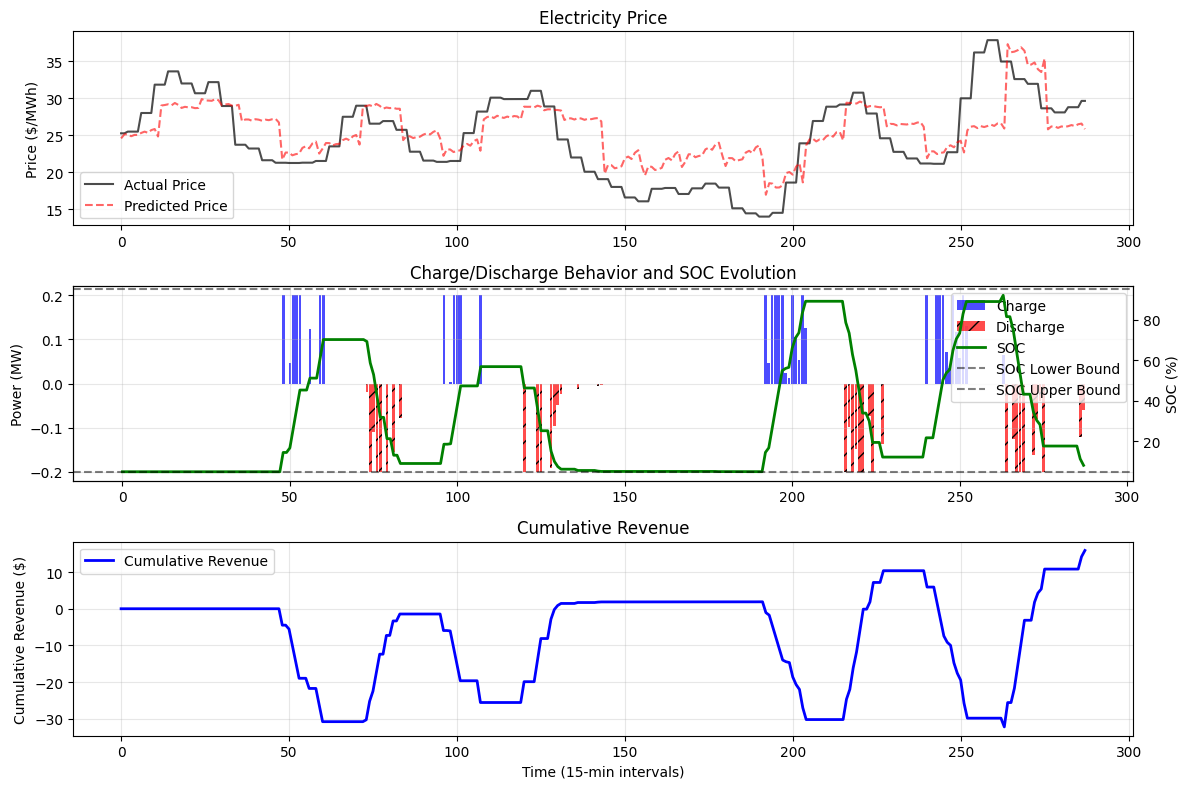

结果已导出到 mpc_predict_results.csv
总收益: $15.90
===== 仿真完成! =====


In [11]:
# ================== 预测+MPC ==================
# ================== 主执行函数 ==================
if __name__ == "__main__":
    print("===== 储能系统MPC+预测控制仿真 =====")
    # 创建模拟器
    simulator = MPCStorageSimulator(H=FORCAST_HORIZON)
    
    # 运行仿真
    print("运行MPC+预测仿真...")
    start_time = time.time()
    results = simulator.run_simulation(predict_prices)
    total_time = time.time() - start_time
    
    if results:
        print(f"MPC仿真完成! 耗时: {total_time:.2f}秒")
        
        # 生成报告
        simulator.generate_report(results)
        
        # 可视化结果
        simulator.visualize_results(results)
        
        # 导出详细数据
        #计算每步收益
        
        each_revenue = ([
            results['actions']['discharge'][t] * true_prices[t] * simulator.storage.efficiency -
            results['actions']['charge'][t] * true_prices[t] / simulator.storage.efficiency
            for t in range(NUM_STEPS)
        ])
        cumulative_revenue  = np.cumsum(each_revenue)
        total_revenue_value = cumulative_revenue[-1]
        
        df = pd.DataFrame({
            'Time': np.arange(NUM_STEPS),
            'Price': true_prices,
            'predict_Price': predict_prices,
            'Charge_Power': results['actions']['charge'],
            'Discharge_Power': results['actions']['discharge'],
            'SOC': results['soc'],
            'Revenue': each_revenue,
        })
        filename = "mpc_predict_results.csv"
        df.to_csv(filename, index=False)
        print(f"结果已导出到 {filename}")
        
        # 打印最终收益
        print(f"总收益: ${total_revenue_value:.2f}")
    else:
        print("MPC仿真失败!")
    
    print("===== 仿真完成! =====")

===== 储能系统全局优化 =====
Initializing Energy Storage with capacity 2.0 MWh
运行全局优化...
全局优化完成! 耗时: 0.04秒

Energy Storage Global Optimization Performance Report

Revenue($)      Final SOC(%) Solve Time(s) Violations      Type        
49.50           5.0          0.0423       0               Global Optimization

Energy Storage Parameters:
- Capacity: 2.0 MWh
- Max Charge Power: 0.2 MW
- Max Discharge Power: 0.2 MW
- Charge Efficiency: 0.95
- SOC Range: 5.0%-95.0%



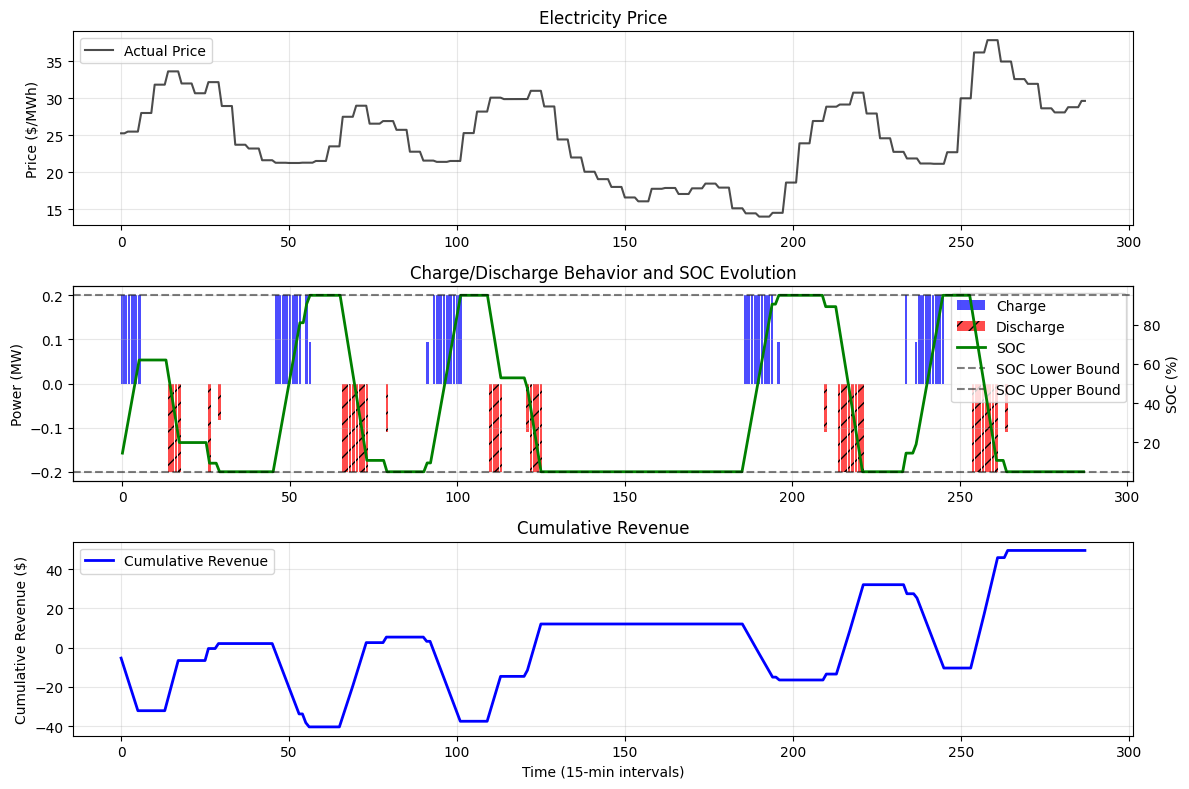

结果已导出到 global_optimization_results.csv
每一步收益: $[np.float64(-5.317894736842106), np.float64(-5.317894736842106), np.float64(-5.366315789473684), np.float64(-5.366315789473684), np.float64(-5.366315789473684), np.float64(-5.366315789473684), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(6.3859), np.float64(6.3859), np.float64(6.3859), np.float64(6.3859), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(6.110399999999999), np.float64(0.0), np.float64(0.0), np.float64(2.535816000000001), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(-4.482105263157895), np.float

In [12]:
# ================== 全局优化器 ==================
class GlobalOptimizer:
    def __init__(self, storage):
        self.storage = storage
        self.env = gp.Env(empty=True)
        self.env.setParam('OutputFlag', 0)
        self.env.start()
    
    def optimize(self, prices):
        start_time = time.time()
        
        try:
            # 创建Gurobi模型
            model = gp.Model("Global_Battery_Optimization", env=self.env)
            model.Params.LogToConsole = 0
            model.Params.TimeLimit = 30  # 30秒求解时间限制
            model.Params.NumericFocus = 2
            
            # 创建变量
            T = len(prices)
            P_char = model.addVars(T, lb=0, ub=self.storage.max_charge, name="P_charge")
            P_dis = model.addVars(T, lb=0, ub=self.storage.max_discharge, name="P_discharge")
            SOC = model.addVars(T+1, lb=self.storage.soc_min, ub=self.storage.soc_max, name="SOC")
            
            # 初始条件约束
            model.addConstr(SOC[0] == self.storage.soc_init, "init_soc")
            
            # 系统动力学约束
            for t in range(T):
                # SOC更新方程
                charge_effect = self.storage.efficiency * P_char[t]/self.storage.capacity
                discharge_effect = - (P_dis[t] / self.storage.efficiency)/self.storage.capacity

                model.addConstr(SOC[t+1] == SOC[t] + charge_effect + discharge_effect, f"soc_dynamics_{t}")
                
                # 互斥约束：不能同时充放电
                bin_var = model.addVar(vtype=GRB.BINARY, name=f"bin_{t}")
                M = self.storage.max_charge + self.storage.max_discharge
                model.addConstr(P_char[t] <= bin_var * M, f"char_cons_{t}")
                model.addConstr(P_dis[t] <= (1 - bin_var) * M, f"dis_cons_{t}")
            
            # 目标函数：最大化总收益
            revenue = gp.quicksum(
                (P_dis[t] * prices[t] * self.storage.efficiency) - 
                (P_char[t] * prices[t] / self.storage.efficiency)
                for t in range(T))
            model.setObjective(revenue, GRB.MAXIMIZE)
            
            # 求解优化
            model.optimize()
            
            # 检查求解状态
            if model.status == GRB.OPTIMAL or model.status == GRB.TIME_LIMIT:
                # 提取结果
                charge_power = [P_char[t].X for t in range(T)]
                discharge_power = [P_dis[t].X for t in range(T)]
                soc = [SOC[t].X for t in range(T+1)]
                
                # 计算总收益
                total_revenue = model.ObjVal
                
                # 计算各时段收益
                each_revenue = [
                    (discharge_power[t] * prices[t] * self.storage.efficiency) -
                    (charge_power[t] * prices[t] / self.storage.efficiency)
                    for t in range(T)
                ]
                
                # 检查约束违规
                constraint_violation = sum(
                    1 for t in range(1, T+1) 
                    if soc[t] < self.storage.soc_min or soc[t] > self.storage.soc_max
                )
                
                return {
                    'actions': {
                        'charge': np.array(charge_power),
                        'discharge': np.array(discharge_power)
                    },
                    'soc': np.array(soc[1:]),  # 从第1时段开始
                    'revenue': total_revenue,
                    'solve_time': time.time() - start_time,
                    'solve_time_min': 0,  # 全局优化只有一次求解
                    'solve_time_max': 0,
                    'solve_times': np.zeros(T),
                    'end_soc': soc[-1],
                    'constraint_violation': constraint_violation,
                    'each_revenue': each_revenue,  # 全局优化使用完美预测
                    'type': 'Global Optimization'
                }
            else:
                print(f"全局优化求解失败！状态码: {model.status}")
                return None
        except gp.GurobiError as e:
            print(f"Gurobi错误: {e}")
            return None
        except Exception as e:
            print(f"未知错误: {e}")
            return None

# ================== 结果可视化 ==================
def visualize_global_results(results, storage, true_prices):
    """可视化全局优化结果，格式与MPC相同"""
    if not results:
        print("没有结果可供可视化!")
        return
    
    # 创建3个子图的布局
    fig, axes = plt.subplots(3, 1, figsize=(12, 8))
    fig.tight_layout(pad=5.0)
    
    # 1. 电价图
    ax1 = axes[0]
    # 反标准化电价: (norm_price * std) + mean
    ax1.plot(true_prices, 'k-', label='Actual Price', alpha=0.7)
    ax1.set_ylabel('Price ($/MWh)')
    ax1.set_title('Electricity Price')
    ax1.grid(alpha=0.3)
    ax1.legend()
    
    # 2. 充放电行为和SOC变化
    ax2 = axes[1]
    # 创建第二个Y轴用于SOC
    ax2_soc = ax2.twinx()
    
    # 绘制充放电柱状图
    actions = results['actions']
    # 充电功率 (正值)
    ax2.bar(np.arange(NUM_STEPS), actions['charge'], 
            width=0.8, color='b', alpha=0.7,
            label="Charge")
    
    # 放电功率 (负值)
    ax2.bar(np.arange(NUM_STEPS), -actions['discharge'], 
            width=0.8, color='r', alpha=0.7,
            hatch='//', label="Discharge")
    
    # 绘制SOC折线图
    soc_data = results['soc']
    ax2_soc.plot(np.arange(NUM_STEPS), soc_data * 100, 'g-', 
                 linewidth=2, label="SOC")
    
    # 添加SOC限制线
    ax2_soc.axhline(storage.soc_min * 100, color='k', linestyle='--', alpha=0.5, label='SOC Lower Bound')
    ax2_soc.axhline(storage.soc_max * 100, color='k', linestyle='--', alpha=0.5, label='SOC Upper Bound')
    
    ax2.set_ylabel('Power (MW)')
    ax2_soc.set_ylabel('SOC (%)')
    ax2.set_title('Charge/Discharge Behavior and SOC Evolution')
    ax2.grid(alpha=0.3)
    
    # 合并图例
    lines, labels = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_soc.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper right')
    
    # 3. 累计收益
    ax3 = axes[2]
    # 计算累计收益
    revenue_cum = np.cumsum([
        actions['discharge'][t] * true_prices[t] * storage.efficiency -
        actions['charge'][t] * true_prices[t] / storage.efficiency
        for t in range(NUM_STEPS)
    ]) 
    
    ax3.plot(revenue_cum, 'b-', 
             linewidth=2, 
             label="Cumulative Revenue")
    
    ax3.set_ylabel('Cumulative Revenue ($)')
    ax3.set_xlabel('Time (15-min intervals)')
    ax3.set_title('Cumulative Revenue')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('global_optimization_results.png', dpi=300)
    plt.show()

# ================== 性能报告 ==================
def generate_global_report(results, storage):
    """生成全局优化的性能报告"""
    if not results:
        print("没有结果可供报告!")
        return
    
    print("\n" + "="*60)
    print("Energy Storage Global Optimization Performance Report")
    print("="*60)
    
    # 表头
    print("\n{:<15} {:<12} {:<12} {:<15} {:<12}".format(
        "Revenue($)", "Final SOC(%)", "Solve Time(s)", "Violations", "Type"
    ))
    
    # 表格内容
    print("{:<15.2f} {:<12.1f} {:<12.4f} {:<15} {:<12}".format(
        results['revenue'] ,
        results['end_soc'] * 100,
        results['solve_time'],
        results['constraint_violation'],
        results['type']
    ))
    
    # 储能信息
    print("\nEnergy Storage Parameters:")
    print(f"- Capacity: {storage.capacity} MWh")
    print(f"- Max Charge Power: {storage.max_charge} MW")
    print(f"- Max Discharge Power: {storage.max_discharge} MW")
    print(f"- Charge Efficiency: {storage.efficiency}")
    print(f"- SOC Range: {storage.soc_min*100}%-{storage.soc_max*100}%")
    
    print("\n" + "="*60)

# ================== 主执行函数 ==================
if __name__ == "__main__":
    print("===== 储能系统全局优化 =====")
    
    # # 加载电价数据
    # DATA_PATH = "./data/test_prices.csv"
    # full_data = pd.read_csv(DATA_PATH)
    
    # # 提取电价数据并进行Z-score标准化
    # prices = full_data.iloc[:, -2].values

    # # 选取连续96时段作为测试数据
    # start_idx = 0
    # test_prices = prices[start_idx:start_idx+96]
    # true_prices = test_prices.copy()
    
    # 创建储能系统
    storage = EnergyStorage()
    print(f"Initializing Energy Storage with capacity {storage.capacity} MWh")
    
    # 创建全局优化器
    optimizer = GlobalOptimizer(storage)
    
    # 运行全局优化
    print("运行全局优化...")
    start_time = time.time()
    results = optimizer.optimize(true_prices)
    total_time = time.time() - start_time
    
    if results:
        print(f"全局优化完成! 耗时: {total_time:.2f}秒")
        
        # 生成报告
        generate_global_report(results, storage)
        
        # 可视化结果
        visualize_global_results(results, storage, true_prices)
        
        # # 导出详细数据
        # cumulative_revenue = np.cumsum([
        #     results['actions']['discharge'][t] * true_prices[t] * storage.efficiency -
        #     results['actions']['charge'][t] * true_prices[t] / storage.efficiency
        #     for t in range(NUM_STEPS)
        # ])
        
        df = pd.DataFrame({
            'Time': np.arange(NUM_STEPS),
            'Price': true_prices,
            'Charge_Power': results['actions']['charge'],
            'Discharge_Power': results['actions']['discharge'],
            'SOC': results['soc'],
            'Revenue': results['each_revenue'],
        })
        filename = "global_optimization_results.csv"
        df.to_csv(filename, index=False)
        print(f"结果已导出到 {filename}")
        
        # 打印最终收益
        print(f"每一步收益: ${results['each_revenue']}")
        print(f"总收益: ${results['revenue']:.2f}")
    else:
        print("全局优化失败!")
    
    print("===== 优化完成! =====")

In [ ]:
# ================== 不同步数灵敏度分析===================

In [ ]:
# ================== 模拟执行框架 ==================
class MPCStorageSimulator:
    def __init__(self, storage_params=None, H=24):
        # 创建储能系统
        self.storage = EnergyStorage()
        print(f"Initializing Energy Storage with capacity {self.storage.capacity} MWh")
        if storage_params:
            for key, value in storage_params.items():
                setattr(self.storage, key, value)
        
        # 创建MPC控制器
        print(f"Initializing MPC Controller with horizon H={H} steps ({H*0.25} hours)")
        self.controller = GurobiMPCController(self.storage, H=H)
        
        # 存储结果
        self.results = {}
    
    def run_simulation(self, price_sequence):
        # 初始化记录
        actions = {'charge': np.zeros(NUM_STEPS), 'discharge': np.zeros(NUM_STEPS)}
        soc_trace = np.zeros(NUM_STEPS)
        revenues = np.zeros(NUM_STEPS)
        solve_times = np.zeros(NUM_STEPS)
        current_soc = self.storage.soc_init
        
        # 逐时段滚动优化
        for t in range(NUM_STEPS):
            # 1. 生成电价预测 (使用真实值)
            price_forecast = self.controller.forecast_prices(t, price_sequence)
            # print(f"Time {t}: Price Forecast: {price_forecast}")
            
            # 2. 求解MPC优化
            P_char, P_dis = self.controller.solve_step(current_soc, price_forecast)
            # print(f"Time {t}: Charge Power: {P_char}, Discharge Power: {P_dis}")

            # 3. 执行决策并更新状态
            revenue = (P_dis * price_sequence[t] * self.storage.efficiency -
                      P_char * price_sequence[t] / self.storage.efficiency)
            # print(f"Time {t}: Revenue: {revenue:.2f},price: {price_sequence[t]:.2f}")
            # 更新SOC (考虑时间间隔)
            energy_change = (self.storage.efficiency * P_char - 
                           P_dis / self.storage.efficiency)
            # print(f"Time {t}:  SOC Change: {energy_change / self.storage.capacity:.2f}")
            current_soc += energy_change / self.storage.capacity
            current_soc = np.clip(current_soc, self.storage.soc_min, self.storage.soc_max)
            
            # 4. 记录结果
            actions['charge'][t] = P_char
            actions['discharge'][t] = P_dis
            soc_trace[t] = current_soc
            revenues[t] = revenue
            solve_times[t] = self.controller.last_solve_time

        # 计算总收益
        total_revenue = np.sum(revenues)
        
        # 检查约束违规
        constraint_violation = np.sum(
            (soc_trace < self.storage.soc_min) | 
            (soc_trace > self.storage.soc_max)
        )
        
        return {
            'actions': actions,
            'soc': soc_trace,
            'revenue': total_revenue,
            'each_revenue': revenues,
            'end_soc': soc_trace[-1],
            'constraint_violation': constraint_violation
        }
    
    def visualize_results(self, results):
        """可视化仿真结果"""
        if not results:
            print("No results available for visualization!")
            return
        
        # 创建3个子图的布局
        fig, axes = plt.subplots(3, 1, figsize=(12, 8))
        fig.tight_layout(pad=5.0)
        
        # 1. 电价图
        ax1 = axes[0]
        # 反标准化电价: (norm_price * std) + mean
        ax1.plot(true_prices, 'k-', label='Actual Price', alpha=0.7)
        ax1.plot(predict_prices, 'r--', label='Predicted Price', alpha=0.6)
        ax1.set_ylabel('Price ($/MWh)')
        ax1.set_title('Electricity Price')
        ax1.grid(alpha=0.3)
        ax1.legend()
        
        # 2. 充放电行为和SOC变化
        ax2 = axes[1]
        # 创建第二个Y轴用于SOC
        ax2_soc = ax2.twinx()
        
        # 绘制充放电柱状图
        actions = results['actions']
        # 充电功率 (正值)
        ax2.bar(np.arange(NUM_STEPS), actions['charge'], 
                width=0.8, color='b', alpha=0.7,
                label="Charge")
        
        # 放电功率 (负值)
        ax2.bar(np.arange(NUM_STEPS), -actions['discharge'], 
                width=0.8, color='r', alpha=0.7,
                hatch='//', label="Discharge")
        
        # 绘制SOC折线图
        soc_data = results['soc']
        ax2_soc.plot(np.arange(NUM_STEPS), soc_data * 100, 'g-', 
                     linewidth=2, label="SOC")
        
        # 添加SOC限制线
        ax2_soc.axhline(self.storage.soc_min * 100, color='k', linestyle='--', alpha=0.5, label='SOC Lower Bound')
        ax2_soc.axhline(self.storage.soc_max * 100, color='k', linestyle='--', alpha=0.5, label='SOC Upper Bound')
        
        ax2.set_ylabel('Power (MW)')
        ax2_soc.set_ylabel('SOC (%)')
        ax2.set_title('Charge/Discharge Behavior and SOC Evolution')
        ax2.grid(alpha=0.3)
        
        # 合并图例
        lines, labels = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2_soc.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper right')
        
        # 3. 累计收益
        ax3 = axes[2]
        # 计算累计收益
        revenue_cum = np.cumsum([
            actions['discharge'][t] * true_prices[t] * self.storage.efficiency -
            actions['charge'][t] * true_prices[t] / self.storage.efficiency
            for t in range(NUM_STEPS)
        ]) 
        
        ax3.plot(revenue_cum, 'b-', 
                 linewidth=2, 
                 label="Cumulative Revenue")
        
        ax3.set_ylabel('Cumulative Revenue ($)')
        ax3.set_xlabel('Time (15-min intervals)')
        ax3.set_title('Cumulative Revenue')
        ax3.legend()
        ax3.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('mpc_results.png', dpi=300)
        plt.show()
        
    
    def generate_report(self, results):
        """生成性能报告"""
        if not results:
            print("No results available for reporting!")
            return
        
        print("\n" + "="*60)
        print("Energy Storage MPC Performance Report")
        print("="*60)
        
        # 表头
        print("\n{:<12} {:<15} {:<12} ".format(
            "Revenue($)", "Final SOC(%)", "Violations"
        ))
        
        # 表格内容
        print("{:<12.2f} {:<15.1f} {:<12.2f}".format(
            results['revenue'] ,
            results['end_soc'] * 100,
            results['constraint_violation']
        ))
        
        # 储能信息
        print("\nEnergy Storage Parameters:")
        print(f"- Capacity: {self.storage.capacity} MWh")
        print(f"- Max Charge Power: {self.storage.max_charge} MW")
        print(f"- Max Discharge Power: {self.storage.max_discharge} MW")
        print(f"- Charge Efficiency: {self.storage.efficiency}")
        print(f"- SOC Range: {self.storage.soc_min*100}%-{self.storage.soc_max*100}%")
        
        # MPC信息
        print("\nMPC Configuration:")
        print(f"- Prediction Horizon: {self.controller.H} steps ({self.controller.H*0.25} hours)")
        
        print("\n" + "="*60)

# ================== 主执行函数 ==================
# ================== 数据加载与预处理 ==================
DATA_PATH = "./data/test_prices.csv"  # 请替换为实际路径
predict_DATA_PATH = "./forecast/prediction_results.csv"  # 请替换为实际路径
full_data = pd.read_csv(DATA_PATH)
predict_data= pd.read_csv(predict_DATA_PATH)
# 提取电价数据
# prices = full_data.iloc[:, -1].values
all_true_prices = predict_data.iloc[:, -2].values
all_predict_prices = predict_data.iloc[:, -1].values
# 选取连续96时段作为测试数据
start_idx = 0  # 可调整测试起点
NUM_STEPS = 96*15  # 测试步数

true_prices = all_true_prices[start_idx:start_idx+NUM_STEPS]
predict_prices = all_predict_prices[start_idx:start_idx+NUM_STEPS]

#循环计算，测试不同预测step的效果，只关注step和总收益
for H in range(4, 48):  # 从1到12小时
    print(f"===== 测试预测步长 H={H} =====")
    # 创建模拟器
    simulator = MPCStorageSimulator(H=H)
    
    # 运行仿真
    print("运行MPC仿真...")
    start_time = time.time()
    results = simulator.run_simulation(true_prices)
    total_time = time.time() - start_time
    
    if results:
        print(f"MPC仿真完成! 耗时: {total_time:.2f}秒")
        
        # 打印最终收益
        print(f"总收益: ${results['revenue']:.2f}")
    else:
        print("MPC仿真失败!")
    
    print("===== 测试完成! =====")
    # 记录结果
    if 'test_results' not in locals():
        test_results = []
    test_results.append({
        'H': H,
        'revenue': results['revenue'] if results else None
    })


===== 测试预测步长 H=4 =====
Initializing Energy Storage with capacity 2.0 MWh
Initializing MPC Controller with horizon H=4 steps (1.0 hours)
运行MPC仿真...
Time 0: Charge Power: 0.0, Discharge Power: 0.0
Time 0: Revenue: 0.00,price: 25.26
Time 0:  SOC Change: 0.00
Time 1: Charge Power: 0.0, Discharge Power: 0.0
Time 1: Revenue: 0.00,price: 25.26
Time 1:  SOC Change: 0.00
Time 2: Charge Power: 0.0, Discharge Power: 0.0
Time 2: Revenue: 0.00,price: 25.49
Time 2:  SOC Change: 0.00
Time 3: Charge Power: 0.0, Discharge Power: 0.0
Time 3: Revenue: 0.00,price: 25.49
Time 3:  SOC Change: 0.00
Time 4: Charge Power: 0.0, Discharge Power: 0.0
Time 4: Revenue: 0.00,price: 25.49
Time 4:  SOC Change: 0.00
Time 5: Charge Power: 0.0, Discharge Power: 0.0
Time 5: Revenue: 0.00,price: 25.49
Time 5:  SOC Change: 0.00
Time 6: Charge Power: 0.0, Discharge Power: 0.0
Time 6: Revenue: 0.00,price: 28.00
Time 6:  SOC Change: 0.00
Time 7: Charge Power: 0.0, Discharge Power: 0.0
Time 7: Revenue: 0.00,price: 28.00
Time 7:

KeyboardInterrupt: 

Exception ignored in: 'gurobipy._core.callbackstub'
Traceback (most recent call last):
  File "src\\gurobipy\\callback.pxi", line 101, in gurobipy._core.CallbackClass.callback
  File "C:\Users\Clouds\AppData\Local\Temp\ipykernel_25656\2158721016.py", line 79, in <lambda>
KeyboardInterrupt: 


Time 47: Charge Power: 0.0, Discharge Power: 0.0
Time 47: Revenue: 0.00,price: 21.29
Time 47:  SOC Change: 0.00
Time 48: Charge Power: 0.0, Discharge Power: 0.0
Time 48: Revenue: 0.00,price: 21.29
Time 48:  SOC Change: 0.00
Time 49: Charge Power: 0.0, Discharge Power: 0.0
Time 49: Revenue: 0.00,price: 21.29
Time 49:  SOC Change: 0.00
Time 50: Charge Power: 0.0, Discharge Power: 0.0
Time 50: Revenue: 0.00,price: 21.26
Time 50:  SOC Change: 0.00
Time 51: Charge Power: 0.0, Discharge Power: 0.0
Time 51: Revenue: 0.00,price: 21.26
Time 51:  SOC Change: 0.00
Time 52: Charge Power: 0.0, Discharge Power: 0.0
Time 52: Revenue: 0.00,price: 21.26
Time 52:  SOC Change: 0.00
Time 53: Charge Power: 0.0, Discharge Power: 0.0
Time 53: Revenue: 0.00,price: 21.26
Time 53:  SOC Change: 0.00
Time 54: Charge Power: 0.0, Discharge Power: 0.0
Time 54: Revenue: 0.00,price: 21.30
Time 54:  SOC Change: 0.00
Time 55: Charge Power: 0.0, Discharge Power: 0.0
Time 55: Revenue: 0.00,price: 21.30
Time 55:  SOC Chang

KeyboardInterrupt: 

Exception ignored in: 'gurobipy._core.callbackstub'
Traceback (most recent call last):
  File "src\\gurobipy\\callback.pxi", line 101, in gurobipy._core.CallbackClass.callback
  File "C:\Users\Clouds\AppData\Local\Temp\ipykernel_25656\2158721016.py", line 79, in <lambda>
KeyboardInterrupt: 


Time 81: Charge Power: 0.0, Discharge Power: 0.09392200994491577
Time 81: Revenue: 2.40,price: 26.91
Time 81:  SOC Change: -0.05
Time 82: Charge Power: 0.0, Discharge Power: 0.04696100497245788
Time 82: Revenue: 1.15,price: 25.73
Time 82:  SOC Change: -0.02
Time 83: Charge Power: 0.0, Discharge Power: 0.02348050248622894
Time 83: Revenue: 0.57,price: 25.73
Time 83:  SOC Change: -0.01
Time 84: Charge Power: 0.0, Discharge Power: 0.01174025124311447
Time 84: Revenue: 0.29,price: 25.73
Time 84:  SOC Change: -0.01
Time 85: Charge Power: 0.0, Discharge Power: 0.005870125621557235
Time 85: Revenue: 0.14,price: 25.73
Time 85:  SOC Change: -0.00
Time 86: Charge Power: 0.0, Discharge Power: 0.002935062810778614
Time 86: Revenue: 0.06,price: 22.78
Time 86:  SOC Change: -0.00
Time 87: Charge Power: 0.0, Discharge Power: 0.001467531405389307
Time 87: Revenue: 0.03,price: 22.78
Time 87:  SOC Change: -0.00
Time 88: Charge Power: 0.0, Discharge Power: 0.0007337657026946502
Time 88: Revenue: 0.02,pric